# Day 7 — Sub-Experiment 1 Analysis

Goal: Analyze inference-time missing-wedge angle error.

Fixed model trained at 50°.  
Inference/refinement was run with mw_angle = 30, 40, 50, 60, 70 degrees.

Questions:
1. Do XZ slices visibly degrade when the inference angle is wrong?
2. Which angle gives the most isotropic Fourier power?
3. Does the qualitative result agree with the FSC curves from Day 6?

In [15]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

from ddw.utils.mrctools import load_mrc_data

In [16]:
# === EDIT THIS IF NEEDED ===
PROJECT_ROOT = Path("../../").resolve()   # depends on where your notebook is located
print(PROJECT_ROOT)

ANGLE_DIR = PROJECT_ROOT / "results" / "angle_sweep"
FIG_DIR = PROJECT_ROOT / "figures" / "day7_subexp1"
OUT_DIR = PROJECT_ROOT / "results" / "day7_subexp1"

FIG_DIR.mkdir(parents=True, exist_ok=True)
OUT_DIR.mkdir(parents=True, exist_ok=True)

angles = [30, 40, 50, 60, 70]


volume_paths = {}

for angle in angles:
    volume_paths[angle] = {
        "even": ANGLE_DIR / f"tomo_even_frames_mw{angle}_refined.rec",
        "odd": ANGLE_DIR / f"tomo_odd_frames_mw{angle}_refined.rec",
    }

#volume_paths

C:\Users\chris\Desktop\Fabio\semester-project-deepdewedge


In [17]:
def load_volume(path):
    vol = load_mrc_data(path)
    if isinstance(vol, torch.Tensor):
        vol = vol.cpu().numpy()
    return vol.astype(np.float32)

In [18]:
volumes = {}

for angle in angles:
    volumes[angle] = {}

    for key, path in volume_paths[angle].items():
        print(f"Loading angle={angle}, type={key}: {path.name}")
        volumes[angle][key] = load_volume(path)
        print("  shape:", volumes[angle][key].shape)

Loading angle=30, type=even: tomo_even_frames_mw30_refined.rec
  shape: (209, 1280, 550)
Loading angle=30, type=odd: tomo_odd_frames_mw30_refined.rec
  shape: (209, 1280, 550)
Loading angle=40, type=even: tomo_even_frames_mw40_refined.rec
  shape: (209, 1280, 550)
Loading angle=40, type=odd: tomo_odd_frames_mw40_refined.rec
  shape: (209, 1280, 550)
Loading angle=50, type=even: tomo_even_frames_mw50_refined.rec
  shape: (209, 1280, 550)
Loading angle=50, type=odd: tomo_odd_frames_mw50_refined.rec
  shape: (209, 1280, 550)
Loading angle=60, type=even: tomo_even_frames_mw60_refined.rec
  shape: (209, 1280, 550)
Loading angle=60, type=odd: tomo_odd_frames_mw60_refined.rec
  shape: (209, 1280, 550)
Loading angle=70, type=even: tomo_even_frames_mw70_refined.rec
  shape: (209, 1280, 550)
Loading angle=70, type=odd: tomo_odd_frames_mw70_refined.rec
  shape: (209, 1280, 550)


In [19]:
def percentile_normalize(img, p_low=1, p_high=99):
    lo, hi = np.percentile(img, [p_low, p_high])
    img = np.clip(img, lo, hi)
    return (img - lo) / (hi - lo + 1e-8)


def get_xy_slice(vol, z_idx=None):
    if z_idx is None:
        z_idx = vol.shape[0] // 2
    return vol[z_idx, :, :]


def get_xz_slice(vol, y_idx=None):
    if y_idx is None:
        y_idx = vol.shape[1] // 2
    return vol[:, y_idx, :]


def get_yz_slice(vol, x_idx=None):
    if x_idx is None:
        x_idx = vol.shape[2] // 2
    return vol[:, :, x_idx]

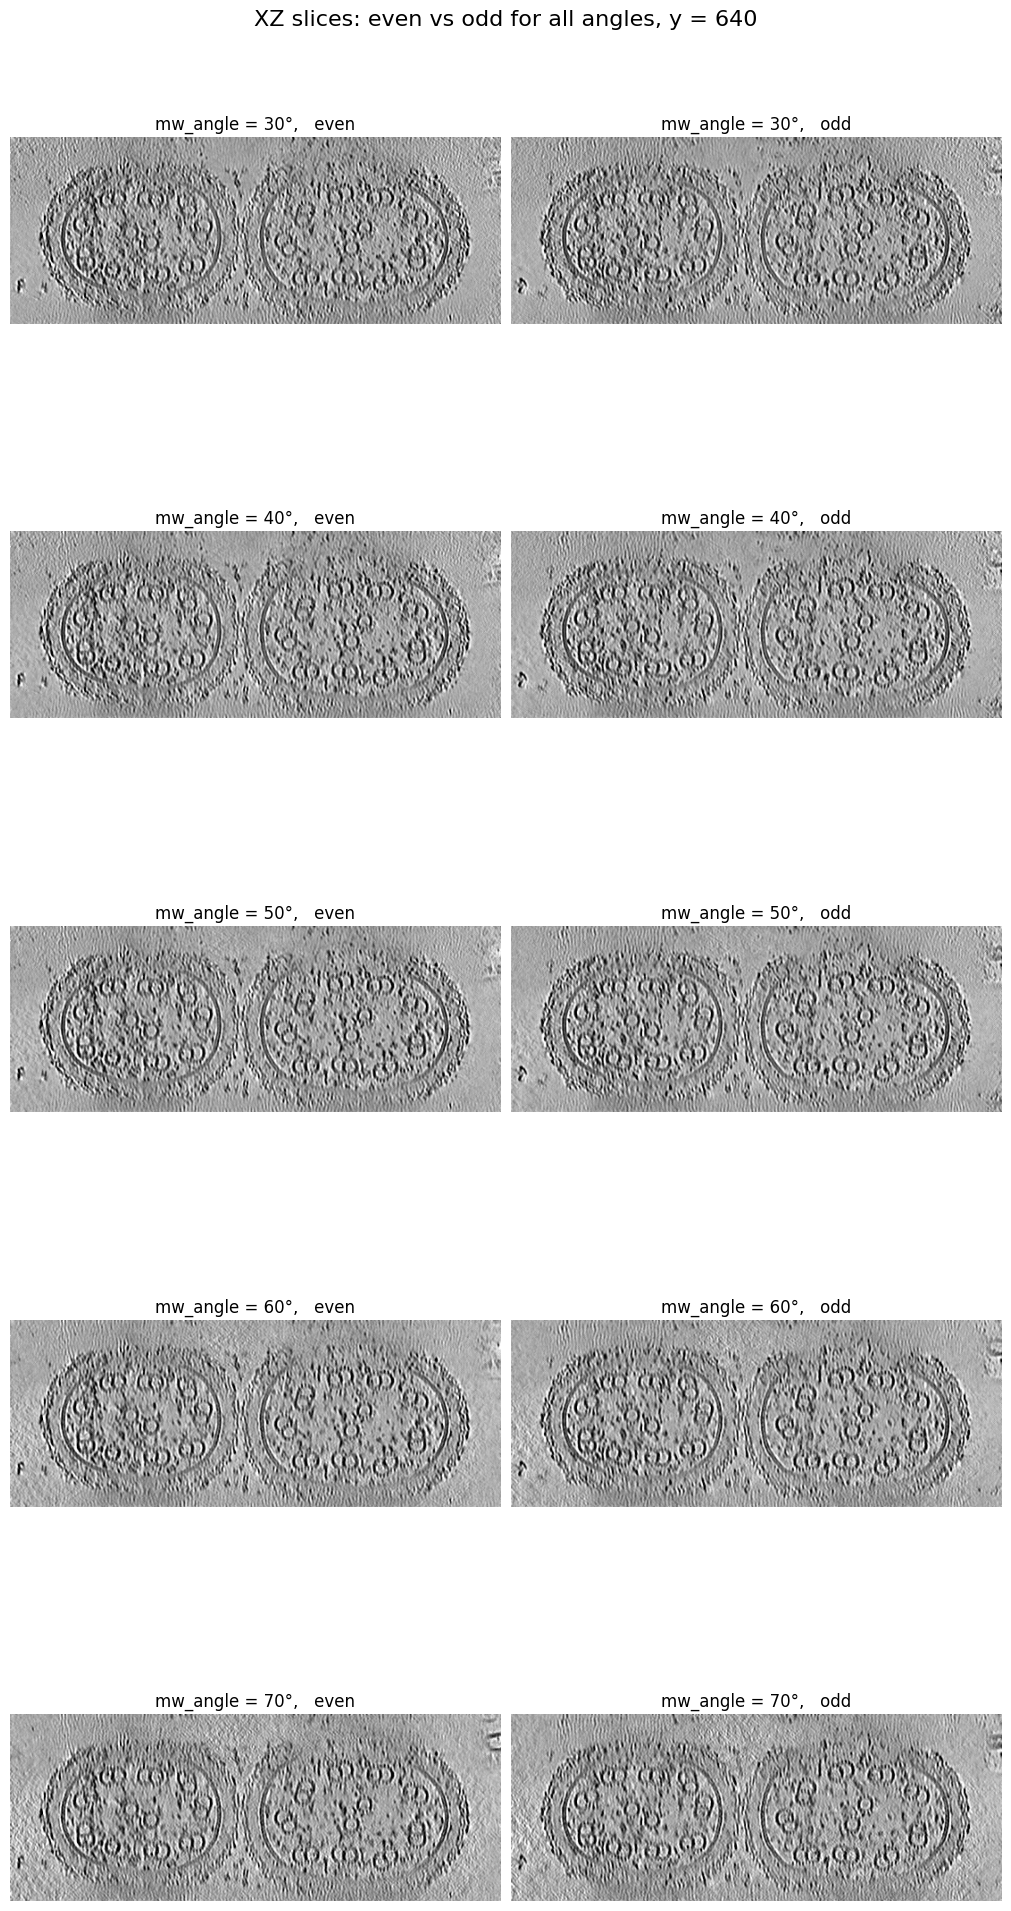

In [25]:
kind_left = "even"
kind_right = "odd"

# Same y-slice for all angles, based on baseline angle 50
y_idx = volumes[50]["even"].shape[1] // 2

fig, axes = plt.subplots(
    len(angles), 2,
    figsize=(10, 4 * len(angles)),
    constrained_layout=True
)

for row, angle in enumerate(angles):
    for col, key in enumerate([kind_left, kind_right]):
        vol = volumes[angle][key]
        xz = get_xz_slice(vol, y_idx=y_idx)

        axes[row, col].imshow(percentile_normalize(xz), cmap="gray", origin="lower")
        axes[row, col].set_title(f"mw_angle = {angle}°,   {key}")
        axes[row, col].axis("off")

fig.suptitle(f"XZ slices: even vs odd for all angles, y = {y_idx}", fontsize=16)
plt.show()

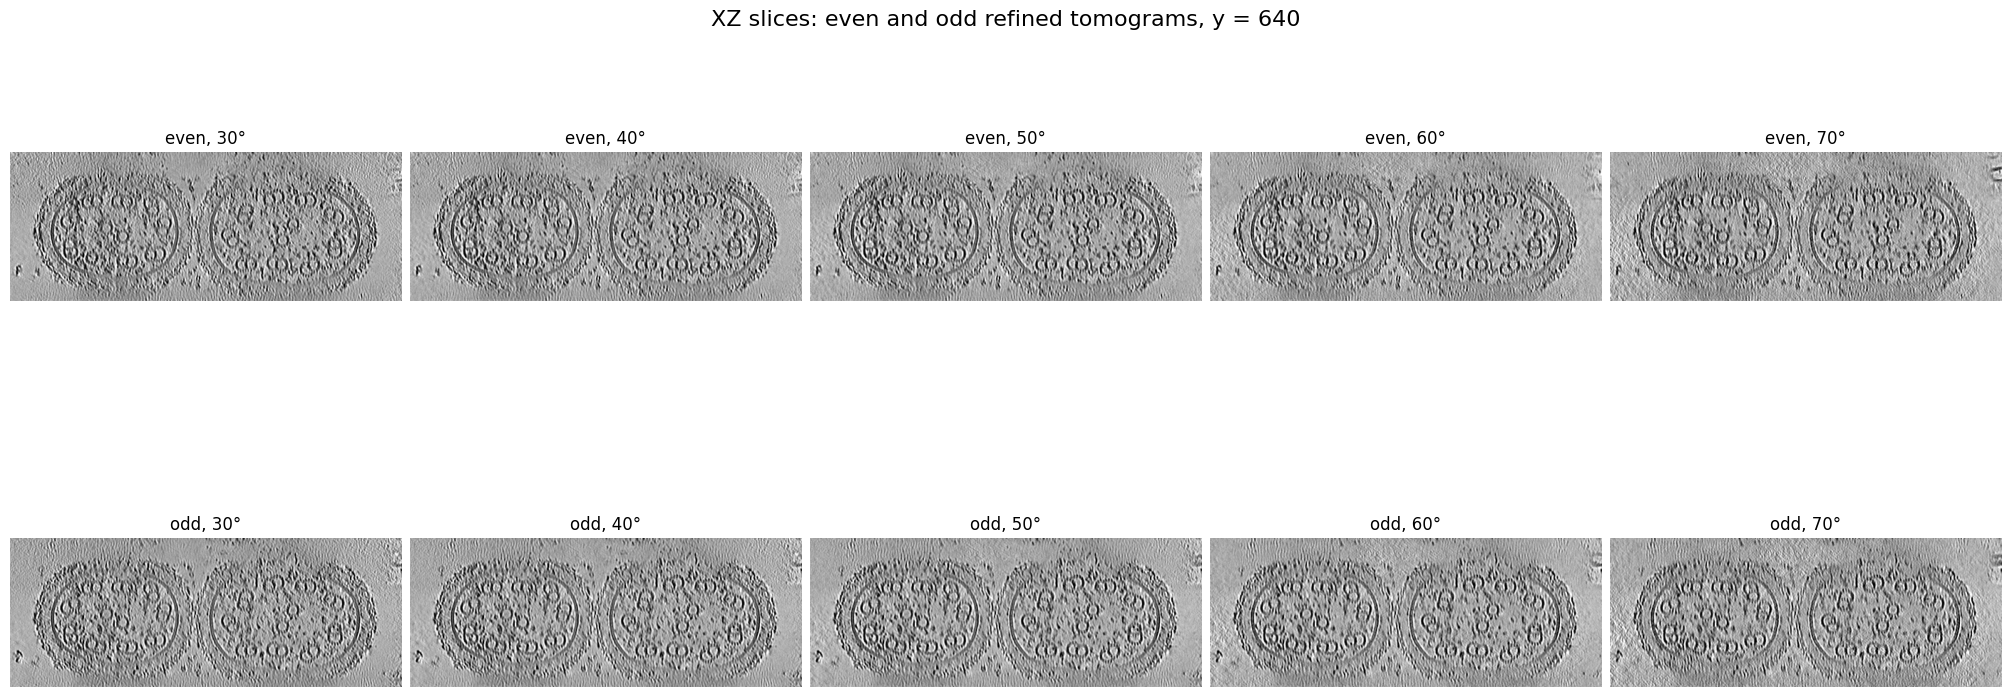

In [23]:
y_idx = volumes[50]["even"].shape[1] // 2

fig, axes = plt.subplots(2, len(angles), figsize=(4 * len(angles), 8), constrained_layout=True)

for col, angle in enumerate(angles):
    for row, key in enumerate(["even", "odd"]):
        vol = volumes[angle][key]
        xz = get_xz_slice(vol, y_idx=y_idx)

        axes[row, col].imshow(percentile_normalize(xz), cmap="gray", origin="lower")
        axes[row, col].set_title(f"{key}, {angle}°")
        axes[row, col].axis("off")

fig.suptitle(f"XZ slices: even and odd refined tomograms, y = {y_idx}", fontsize=16)
plt.show()

For me it is quite hard to say at which angle the quality does visibly degrade. I find 40° and 30° to somewhat unsatisfactory but when looking at it with different lighting or at some other point I also often think they all look pretty similar. (Also top of odd at 70° looks weird)

### ratio = average_power_in_XZ / average_power_in_XY
ratio ≈ 1    → XZ and XY have similar power → more isotropic 

ratio < 1    → XZ has less power → still missing-wedge anisotropy 

ratio > 1    → XZ has more power → maybe overfilled / artifacts / noise

In [31]:
def compute_fourier_power(vol):
    """
    Compute centered 3D Fourier power spectrum.
    vol shape assumed: (z, y, x)
    """
    vol = vol.astype(np.float32)
    vol = vol - np.mean(vol) #subtract the mean, bc if the central fourier point is extremly strong, it can dominate the Power spectrum analysis

    """
    macht aus dem Volumen ein Signal mit Mittelwert ungefähr 0.
    Dadurch vergleichen wir eher die Struktur / Variationen im Tomogramm und nicht den globalen Helligkeits-Offset.
    """
    
    F = np.fft.fftn(vol)
    F = np.fft.fftshift(F)

    power = np.abs(F) ** 2 #Formula for the Power Spectrum
    
    
    return power


"""
def compute_xz_xy_power_ratio(vol, r_min=0.08, r_max=0.35, eps=1e-12):
    
    Compute XZ/XY Fourier power ratio in a medium-frequency annulus.

    Ratio ≈ 1 means similar Fourier power in XZ and XY.
    

    power = compute_fourier_power(vol)

    nz, ny, nx = power.shape
    zc, yc, xc = nz // 2, ny // 2, nx // 2

    #Creates axes with fourier frequencies. 
    fz = np.fft.fftshift(np.fft.fftfreq(nz))
    fy = np.fft.fftshift(np.fft.fftfreq(ny))
    fx = np.fft.fftshift(np.fft.fftfreq(nx))

    # XY plane: kz = 0
    xy_power = power[zc, :, :] 
    FY, FX_xy = np.meshgrid(fy, fx, indexing="ij")
    r_xy = np.sqrt(FX_xy**2 + FY**2)

    # XZ plane: ky = 0
    xz_power = power[:, yc, :]
    FZ, FX_xz = np.meshgrid(fz, fx, indexing="ij")
    r_xz = np.sqrt(FX_xz**2 + FZ**2)

    # compare the same radial frequency band
    mask_xy = (r_xy >= r_min) & (r_xy <= r_max)
    mask_xz = (r_xz >= r_min) & (r_xz <= r_max)

    # log-power average is more stable because Fourier power spans many orders of magnitude
    mean_log_xy = np.mean(np.log10(xy_power[mask_xy] + eps))
    mean_log_xz = np.mean(np.log10(xz_power[mask_xz] + eps))

    ratio = 10 ** (mean_log_xz - mean_log_xy)

    return {
        "ratio_xz_xy": ratio,
        "mean_log_xy": mean_log_xy,
        "mean_log_xz": mean_log_xz,
        "r_min": r_min,
        "r_max": r_max,
    }
"""


def compute_xz_xy_power_ratio_full_plane(vol, eps=1e-12, use_log=True):
    """
    Compare full central XZ Fourier power plane with full central XY Fourier power plane.

    XY Fourier plane: kz = 0  -> power[zc, :, :]
    XZ Fourier plane: ky = 0  -> power[:, yc, :]

    ratio = average XZ power / average XY power
    """

    power = compute_fourier_power(vol)

    nz, ny, nx = power.shape
    zc, yc, xc = nz // 2, ny // 2, nx // 2

    xy_power = power[zc, :, :]   # central XY Fourier plane, kz = 0
    xz_power = power[:, yc, :]   # central XZ Fourier plane, ky = 0

    if use_log:
        # More stable because Fourier power spans many orders of magnitude
        mean_xy = np.mean(np.log10(xy_power + eps))
        mean_xz = np.mean(np.log10(xz_power + eps))
        ratio = 10 ** (mean_xz - mean_xy)
    else:
        mean_xy = np.mean(xy_power)
        mean_xz = np.mean(xz_power)
        ratio = mean_xz / (mean_xy + eps)

    return {
        "ratio_xz_xy": ratio,
        "mean_xy": mean_xy,
        "mean_xz": mean_xz,
        "use_log": use_log,
    }

In [35]:
ratio_results = []

for angle in angles:
    vol = volumes[angle]["even"]

    result = compute_xz_xy_power_ratio_full_plane(
        vol,
        use_log=False
    )

    result["mw_angle"] = angle
    ratio_results.append(result)

ratio_df = pd.DataFrame(ratio_results)
ratio_df = ratio_df[["mw_angle", "ratio_xz_xy", "mean_xy", "mean_xz", "use_log"]]

ratio_df

,mw_angle,ratio_xz_xy,mean_xy,mean_xz,use_log
0,30,6.153666,4.403297e+08,2.709642e+09,False
1,40,6.361867,3.941255e+08,2.507374e+09,False
2,50,6.477922,3.629025e+08,2.350854e+09,False
3,60,6.356938,3.427127e+08,2.178603e+09,False
4,70,6.190554,3.303751e+08,2.045205e+09,False


In [34]:
ratio_results = []

for angle in angles:
    vol = volumes[angle]["odd"]

    result = compute_xz_xy_power_ratio_full_plane(
        vol,
        use_log=False
    )

    result["mw_angle"] = angle
    ratio_results.append(result)

ratio_df = pd.DataFrame(ratio_results)
ratio_df = ratio_df[["mw_angle", "ratio_xz_xy", "mean_xy", "mean_xz", "use_log"]]

ratio_df

,mw_angle,ratio_xz_xy,mean_xy,mean_xz,use_log
0,30,6.153968,4.406485e+08,2.711737e+09,False
1,40,6.364748,3.943447e+08,2.509905e+09,False
2,50,6.479403,3.630735e+08,2.352500e+09,False
3,60,6.364792,3.419987e+08,2.176751e+09,False
4,70,6.196497,3.296781e+08,2.042849e+09,False
